> **⚠️ Dataset Reproduction Notice**
> Due to GitHub's file size limitations, the raw compressed dataset (`listings.csv.gz`) is not hosted in this repository. To execute this notebook locally:
> 1. Download the dataset from Kaggle: https://www.kaggle.com/datasets/ulrikthygepedersen/airbnb-listings
> 2. Place the `listings.csv.gz` file in the same root directory as this notebook.

###Environment Setup & Data Preprocessing

This section initializes the analytical environment and prepares the raw data for visualization.

* **Data Ingestion:** Loads the compressed dataset (`listings.csv.gz`) directly into Pandas to optimize memory usage.
* **Data Formatting:** Cleans the `price` column by stripping currency symbols and commas, converting it to a numerical format for mathematical analysis.
* **Scientific Filtering:** Restricts the dataset to listings with at least 10 reviews, ensuring our quality metrics are based on statistically reliable sample sizes rather than outliers.
* **Dependency Management:** Silently installs `vl-convert-python` to ensure interactive Altair charts are rendered as high-resolution static PNGs. This is critical for displaying the visualizations correctly within GitHub's static file preview.

In [ ]:
import pandas as pd
import numpy as np
import altair as alt

# Read data
df = pd.read_csv(
    "listings.csv.gz",
    compression="gzip",
    encoding="utf-8",
    low_memory=False
)

# Clean price column
df['price'] = (
    df['price']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)

# Keep more reliable listings
df_q = df[df['number_of_reviews'] >= 10].copy()

# Make sure revenue column is numeric
df_q['estimated_revenue_l365d'] = pd.to_numeric(
    df_q['estimated_revenue_l365d'],
    errors='coerce'
)

!pip install -q vl-convert-python

import os
from IPython.display import Image, display

os.makedirs("figures", exist_ok=True)


**Hypthesis/Task B.1:** Identify and map high-value, low-cost "hidden gem" listings across Vienna neighborhoods, and explore whether they cluster in specific areas or room types.

###B.1 Code Logic: Isolating the Hidden Gems

To visualize the "Hidden Gems" of Vienna's Airbnb market, we must first establish strict, data-driven boundaries.

* **Dynamic Thresholding:** The code automatically detects the review score scale (0-5 or 0-100) and filters for listings scoring above a 4.8 equivalent, while simultaneously costing less than or equal to the city-wide median price.
* **Data Aggregation:** We isolate these high-value listings and extract the top 15 neighborhoods with the highest absolute concentration of gems.
* **Visualization Design:** A Stacked Bar Chart is utilized to encode two variables simultaneously: the total volume of gems per neighborhood (x-axis) and the structural makeup of those gems by room type (color). The legend is anchored to the bottom to maximize horizontal space for neighborhood labels.

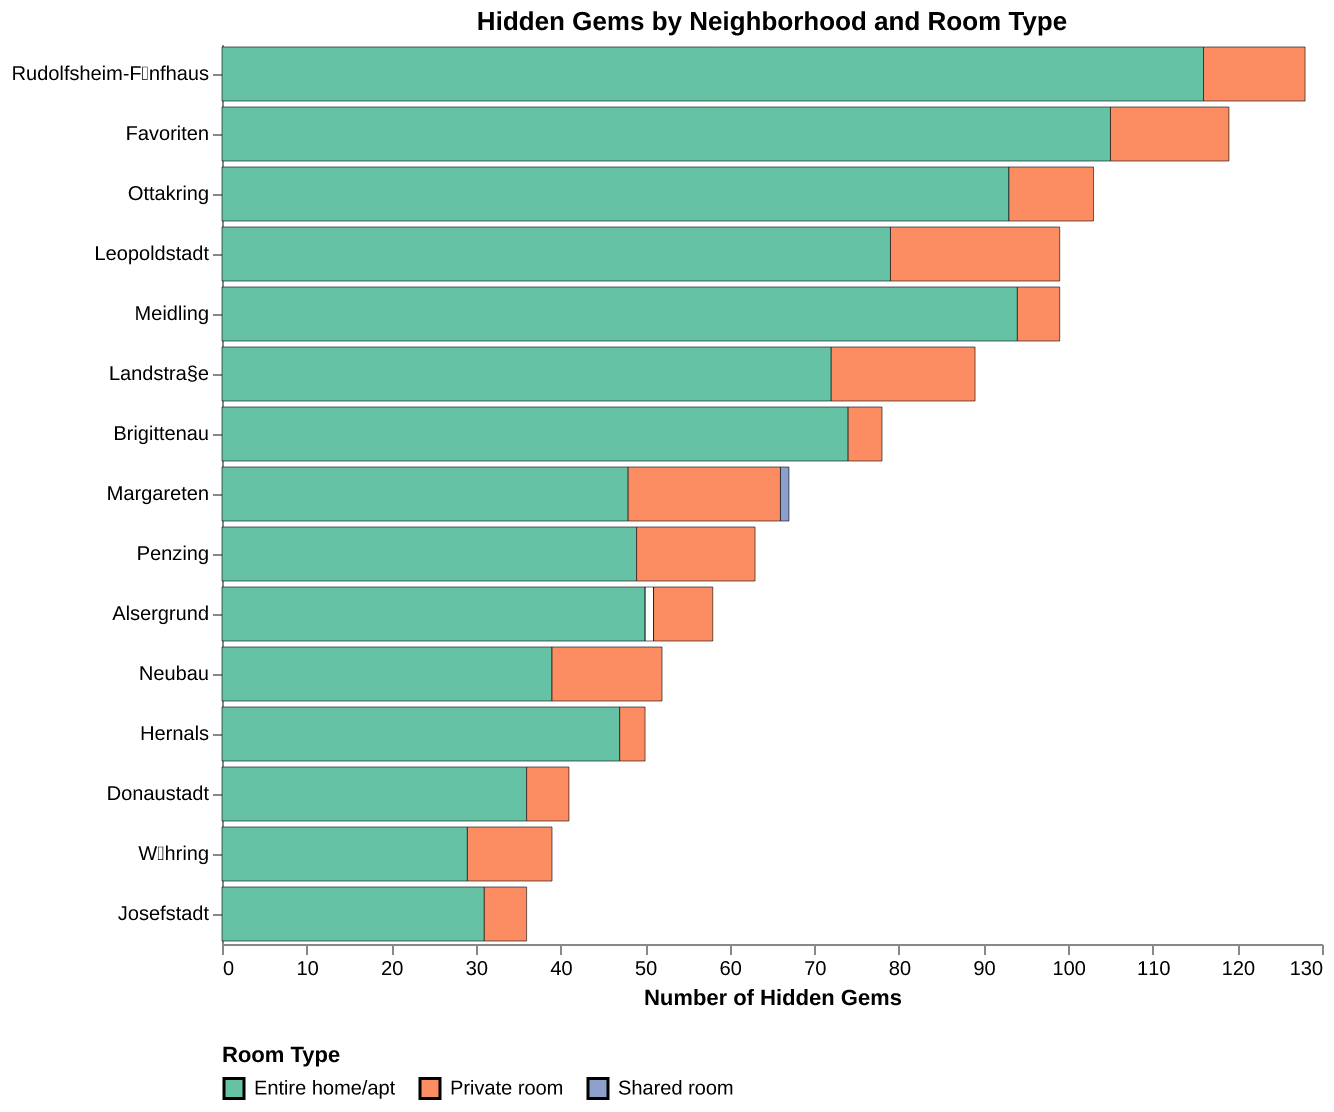

In [ ]:
# -----------------------------
# Plot 1: Hidden Gems
# -----------------------------

# Make sure review score is numeric
df_q['review_scores_rating'] = pd.to_numeric(
    df_q['review_scores_rating'],
    errors='coerce'
)

# Detect whether ratings are on 0-5 scale or 0-100 scale
rating_threshold = 4.8

if df_q['review_scores_rating'].max() > 5:
    rating_threshold = 95

# Define Hidden Gems
# A Hidden Gem is a listing with high rating and below/equal median price
median_price = df_q['price'].median()

df_q['category'] = np.where(
    (df_q['review_scores_rating'] >= rating_threshold) &
    (df_q['price'] <= median_price),
    'Hidden Gem 💎',
    'Other'
)

# Filter Hidden Gems
df_gems = df_q[df_q['category'] == 'Hidden Gem 💎'].copy()

# Top 15 neighbourhoods by number of Hidden Gems
top_hoods = (
    df_gems['neighbourhood_cleansed']
    .value_counts()
    .head(15)
    .index
    .tolist()
)

df_gems_top = df_gems[
    df_gems['neighbourhood_cleansed'].isin(top_hoods)
].copy()

# Stacked bar chart
chart1 = alt.Chart(df_gems_top).mark_bar(
    stroke='black',
    strokeWidth=0.3
).encode(
    x=alt.X(
        'count():Q',
        title='Number of Hidden Gems'
    ),
    y=alt.Y(
        'neighbourhood_cleansed:N',
        sort='-x',
        title=None
    ),
    color=alt.Color(
        'room_type:N',
        scale=alt.Scale(
            domain=['Entire home/apt', 'Private room', 'Shared room'],
            range=['#66c2a5', '#fc8d62', '#8da0cb']
        ),
        title='Room Type',
        legend=alt.Legend(orient='bottom')
    ),
    tooltip=[
        alt.Tooltip('neighbourhood_cleansed:N', title='Neighborhood'),
        alt.Tooltip('room_type:N', title='Room Type'),
        alt.Tooltip('count():Q', title='Count')
    ]
).properties(
    title='Hidden Gems by Neighborhood and Room Type',
    width=550,
    height=450
).configure_view(
    stroke=None
).configure_axis(
    grid=False
)

chart1.save("figures/plot1_hidden_gems.png", scale_factor=2)
display(Image(filename="figures/plot1_hidden_gems.png"))

 This task identifies high-value, low-cost "hidden gem" Airbnb listings across Vienna by constructing a composite value index that benchmarks each listing against its own neighborhood rather than the entire city. A listing qualifies as a hidden gem if its price per person falls below the neighborhood median while its overall rating and value score rank above the 75th percentile within the same neighborhood. Only listings with at least 10 reviews are included to ensure score reliability. The analysis reveals where these gems concentrate geographically and which property types dominate among them. An interactive scatter map pinpoints every gem on the city map with hover details, while a stacked bar chart breaks down the distribution across neighborhoods and room types, providing travelers with a data-driven guide to finding the best-value accommodations.neighborhoods.


**Hypthesis/Task B.2:** Investigate the revenue concentration of Vienna's Airbnb market and identify whether a service quality gap exists between multi-listing hosts and single-listing hosts.

### B.2 Code Logic: Market Concentration & Host Performance

This section shifts the analysis from the traveler's perspective to a macro-market view, investigating revenue distribution and the performance of different host types.

* **Revenue Inequality (Lorenz Curve):** We aggregate total estimated revenue by `host_id` and compute the Gini coefficient mathematically. The Lorenz Curve visualizes this severe inequality, using an annotated point to explicitly highlight the revenue share captured by the top 20% of hosts.
* **Host Segmentation:** Hosts are categorized into 'Single-listing' (independent locals) and 'Multi-listing' (commercial operators) based on their total property count.
* **Service Gap (Dumbbell Plot):** We calculate the mean scores for three human-centric metrics (Cleanliness, Communication, Check-in) across both host segments. The Dumbbell Plot is specifically chosen because it excels at emphasizing the performance *distance* between two distinct groups.
* **Composite Rendering:** Both charts are concatenated vertically to tell a unified story: extreme market concentration does not correlate with superior service quality.

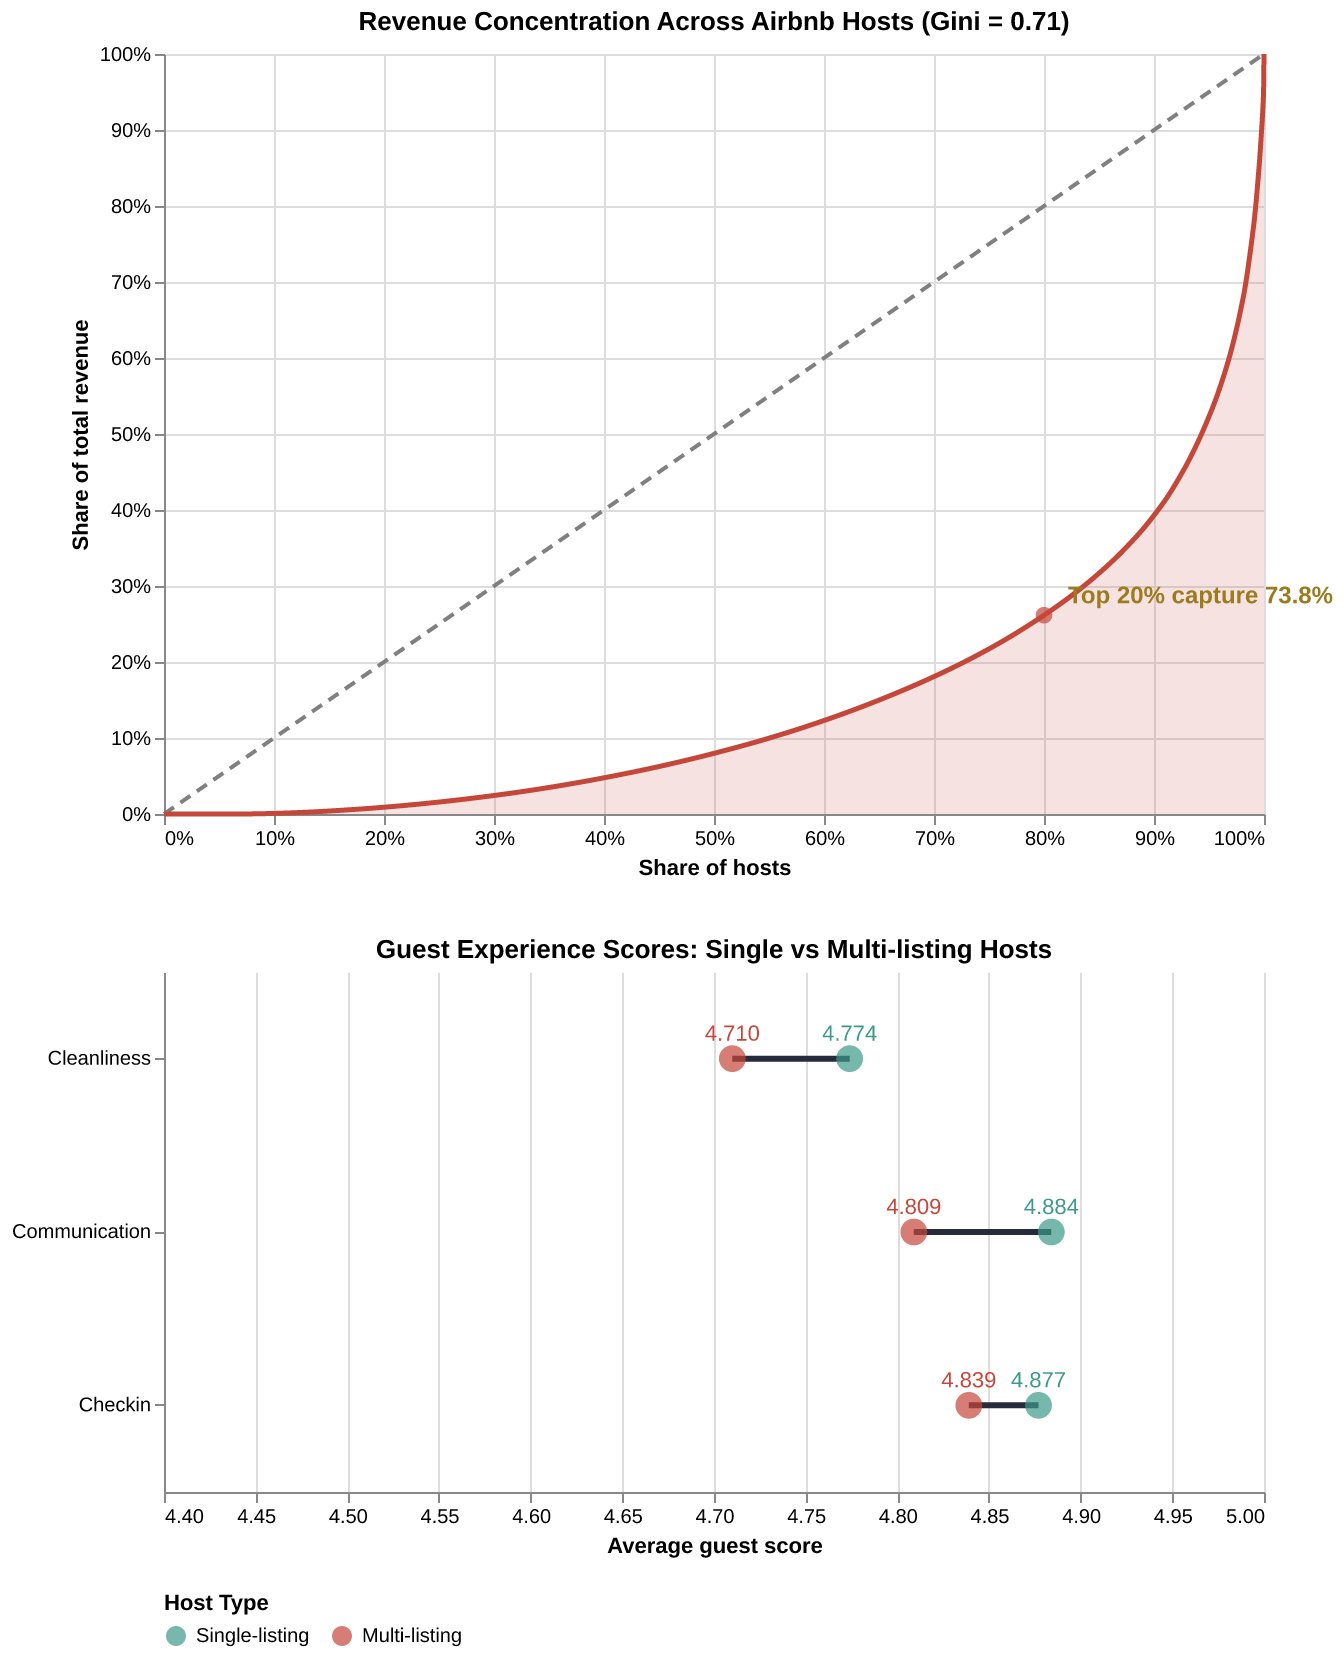

In [ ]:
# -----------------------------
# Plot 2: Lorenz Curve
# Plot 3: Dumbbell Plot
# -----------------------------

# Make sure revenue column is numeric
df_q['estimated_revenue_l365d'] = pd.to_numeric(
    df_q['estimated_revenue_l365d'],
    errors='coerce'
)

# -----------------------------
# Host-level revenue aggregation
# -----------------------------

host_rev = (
    df_q
    .dropna(subset=['estimated_revenue_l365d'])
    .groupby('host_id')
    .agg(
        total_revenue=('estimated_revenue_l365d', 'sum'),
        num_listings=('id', 'count')
    )
    .reset_index()
    .sort_values('total_revenue')
)

# Cumulative percentages for Lorenz curve
host_rev['cum_hosts'] = np.arange(1, len(host_rev) + 1) / len(host_rev)
host_rev['cum_revenue'] = (
    host_rev['total_revenue'].cumsum()
    / host_rev['total_revenue'].sum()
)

# Gini coefficient
revenues = host_rev['total_revenue'].values
n = len(revenues)

gini = (
    (2 * np.sum(np.arange(1, n + 1) * revenues) / (n * np.sum(revenues)))
    - (n + 1) / n
)

# Add origin point for Lorenz curve
lorenz_df = pd.concat([
    pd.DataFrame({'cum_hosts': [0], 'cum_revenue': [0]}),
    host_rev[['cum_hosts', 'cum_revenue']]
], ignore_index=True)

# Equality line
equality_df = pd.DataFrame({
    'x': [0, 1],
    'y': [0, 1]
})

equality = alt.Chart(equality_df).mark_line(
    strokeDash=[6, 4],
    color='gray'
).encode(
    x='x:Q',
    y='y:Q'
)

# Lorenz curve
lorenz = alt.Chart(lorenz_df).mark_area(
    opacity=0.15,
    color='#c4473a',
    line={'color': '#c4473a', 'strokeWidth': 2.5}
).encode(
    x=alt.X(
        'cum_hosts:Q',
        title='Share of hosts',
        axis=alt.Axis(format='%')
    ),
    y=alt.Y(
        'cum_revenue:Q',
        title='Share of total revenue',
        axis=alt.Axis(format='%')
    )
)

# Annotation point: top 20% of hosts
idx_80 = np.searchsorted(host_rev['cum_hosts'], 0.8)

rev_pct = (1 - host_rev.iloc[idx_80]['cum_revenue']) * 100

point_df = pd.DataFrame({
    'x': [host_rev.iloc[idx_80]['cum_hosts']],
    'y': [host_rev.iloc[idx_80]['cum_revenue']],
    'label': [f'Top 20% capture {rev_pct:.1f}%']
})

point = alt.Chart(point_df).mark_point(
    size=70,
    color='#c4473a',
    filled=True
).encode(
    x='x:Q',
    y='y:Q'
)

text = alt.Chart(point_df).mark_text(
    align='left',
    dx=12,
    dy=-10,
    fontSize=12,
    fontWeight='bold',
    color='#9c7b1f'
).encode(
    x='x:Q',
    y='y:Q',
    text='label:N'
)

chart2 = (equality + lorenz + point + text).properties(
    width=550,
    height=380,
    title=f'Revenue Concentration Across Airbnb Hosts (Gini = {gini:.2f})'
)


# -----------------------------
# Dumbbell Plot calculation
# -----------------------------

host_rev['segment'] = np.where(
    host_rev['num_listings'] == 1,
    'Single-listing',
    'Multi-listing'
)

host_seg = host_rev.set_index('host_id')['segment']
df_q['segment'] = df_q['host_id'].map(host_seg)

metrics = [
    'review_scores_cleanliness',
    'review_scores_communication',
    'review_scores_checkin'
]

for m in metrics:
    df_q[m] = pd.to_numeric(df_q[m], errors='coerce')

rows = []

for m in metrics:
    for seg in ['Single-listing', 'Multi-listing']:
        mean_val = (
            df_q[df_q['segment'] == seg][m]
            .dropna()
            .mean()
        )
        rows.append({
            'metric': m.replace('review_scores_', '').title(),
            'segment': seg,
            'score': round(mean_val, 3)
        })

dumbbell_df = pd.DataFrame(rows)

lines_df = (
    dumbbell_df
    .groupby('metric')
    .agg(
        min_score=('score', 'min'),
        max_score=('score', 'max')
    )
    .reset_index()
)

lines = alt.Chart(lines_df).mark_rule(
    strokeWidth=3,
    color='#252b38'
).encode(
    x=alt.X(
        'min_score:Q',
        scale=alt.Scale(domain=[4.4, 5.0]),
        title='Average guest score'
    ),
    x2='max_score:Q',
    y=alt.Y(
        'metric:N',
        title=None,
        sort=['Cleanliness', 'Communication', 'Checkin']
    )
)

dots = alt.Chart(dumbbell_df).mark_point(
    size=180,
    filled=True
).encode(
    x='score:Q',
    y=alt.Y(
        'metric:N',
        sort=['Cleanliness', 'Communication', 'Checkin']
    ),
    color=alt.Color(
        'segment:N',
        scale=alt.Scale(
            domain=['Single-listing', 'Multi-listing'],
            range=['#3d998a', '#c4473a']
        ),
        legend=alt.Legend(
            title='Host Type',
            orient='bottom'
        )
    ),
    tooltip=[
        alt.Tooltip('metric:N', title='Metric'),
        alt.Tooltip('segment:N', title='Host Type'),
        alt.Tooltip('score:Q', title='Average Score', format='.3f')
    ]
)

labels = alt.Chart(dumbbell_df).mark_text(
    dy=-12,
    fontSize=11
).encode(
    x='score:Q',
    y=alt.Y(
        'metric:N',
        sort=['Cleanliness', 'Communication', 'Checkin']
    ),
    text=alt.Text('score:Q', format='.3f'),
    color=alt.Color(
        'segment:N',
        scale=alt.Scale(
            domain=['Single-listing', 'Multi-listing'],
            range=['#3d998a', '#c4473a']
        ),
        legend=None
    )
)

chart3 = (lines + dots + labels).properties(
    width=550,
    height=260,
    title='Guest Experience Scores: Single vs Multi-listing Hosts'
)

final_chart = (chart2 & chart3).configure_view(
    strokeWidth=0
).configure_concat(
    spacing=30
)

final_chart.save("figures/plot2_3_lorenz_dumbbell.png", scale_factor=2)
display(Image(filename="figures/plot2_3_lorenz_dumbbell.png"))

This task investigates the structural concentration of Vienna's Airbnb market and identifies whether revenue dominance comes at the cost of guest experience. By aggregating estimated annual revenue at the host level and sorting hosts by earnings, a Lorenz Curve visually demonstrates the degree of market inequality, summarized by the Gini coefficient. Hosts are segmented into single-listing and multi-listing categories based on their listing count. The analysis then examines whether a service quality gap exists between these segments by comparing average guest scores across three human-centric metrics: cleanliness, communication, and check-in — dimensions directly shaped by host effort rather than property characteristics. A Dumbbell Plot highlights the precise performance difference for each metric, revealing whether market dominance translates to service excellence or exposes an opportunity for quality-focused new entrants.
